# 🚀 01. Preprocesamiento, Limpieza y Normalización de Datasets para TranAD+
**Detección de Anomalías Multivariadas en Pipelines de Data Engineering con Aceleración GPU**

---

### 📌 Contexto y Fundamentación Teórica
Este cuaderno implementa la primera fase del flujo de trabajo de detección de anomalías basado en **TranAD+** (*A Transformer-Based Deep Learning Approach to Anomaly Detection of High-Bandwidth Multivariate Time-Series Satellite Communications*, Yermakov et al., 2025; basado en *TranAD*, Tuli et al., 2022).

En el contexto de **Data Engineering Pipelines**, el sistema supervisa métricas de una infraestructura distribuida:
- **Emisor (Emitter):** Tasa de emisión, latencia, estado del servicio, consumo de CPU y memoria.
- **Airflow Orchestrator:** Tareas de extracción (Kinesis), transformación y carga (PostgreSQL DW), consumo de CPU y memoria de workers/scheduler.
- **Broker y Almacenamiento:** Kinesis Stream Lag y operaciones en PostgreSQL.

### 🎯 Objetivos de este Cuaderno:
1. **Verificación del Entorno y GPU:** Configuración de PyTorch con soporte CUDA.
2. **Carga e Inspección de Datos:** Análisis de series temporales multivariadas procedentes de Prometheus/cAdvisor (`dataset_gen/datasets_finales/train_dataset.csv`, `val_dataset.csv`, `test_dataset.csv`).
3. **Control de Frecuencia y Limpieza:** Verificación de continuidad temporal ($\Delta t = 5\text{ s}$), imputación por *Forward Fill* (`ffill`) y sustitución de nulos.
4. **Normalización MinMax con Scikit-Learn y Protección `clip=True`:** Escalado en rango $[0, 1]$ ajustado exclusivamente en Train (*Zero Data Leakage*), con justificación matemática contra el desbordamiento de atención (*Softmax NaN overflow*) de la fórmula original de TranAD+.
5. **Generación de Ventanas Deslizantes con *Replication Padding*:** Estructuración de ventanas $W_t \in \mathbb{R}^{w \times m}$ según la especificación de TranAD+.
6. **PyTorch `TranADDataset` y `DataLoader` con GPU:** Construcción de tensores optimizados listos para la fase de entrenamiento adversarial del Transformer.
7. **Exportación de Artefactos Procesados:** Almacenamiento estructurado en `processed_data/` para reproducibilidad total.


In [1]:
import os
import json
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Configuración de estilos visuales
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

def set_seed(seed=42):
    '''Fija las semillas aleatorias para garantizar reproducibilidad.'''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
print("✅ Librerías importadas y semillas aleatorias configuradas.")


✅ Librerías importadas y semillas aleatorias configuradas.


## 🖥️ 1. Verificación de Hardware y Aceleración por GPU (CUDA)
Para el entrenamiento del modelo Transformer TranAD+, se aprovecha la aceleración por hardware (GPU con soporte CUDA). Se verifica la disponibilidad y estado de memoria del dispositivo.


In [2]:
# Verificación de dispositivo GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print(f"🔹 PyTorch Version: {torch.__version__}")
print(f"🔹 Dispositivo seleccionado: {device}")

if torch.cuda.is_available():
    gpu_id = torch.cuda.current_device()
    gpu_name = torch.cuda.get_device_name(gpu_id)
    gpu_props = torch.cuda.get_device_properties(gpu_id)
    total_mem_gb = gpu_props.total_memory / (1024 ** 3)
    
    print(f"🔹 GPU Nombre: {gpu_name}")
    print(f"🔹 Capacidad de Cómputo (Compute Capability): {gpu_props.major}.{gpu_props.minor}")
    print(f"🔹 Memoria VRAM Total: {total_mem_gb:.2f} GB")
    print(f"🔹 Multiprocesadores (SMs): {gpu_props.multi_processor_count}")
    
    # Test de asignación en GPU
    x_test = torch.ones((1000, 1000), device=device)
    print(f"✅ Test de tensor en GPU exitoso. Memoria asignada: {torch.cuda.memory_allocated(device)/(1024**2):.2f} MB")
    del x_test
    torch.cuda.empty_cache()
else:
    print("⚠️ ADVERTENCIA: CUDA no está disponible. Se utilizará la CPU.")
print("=" * 60)


🔹 PyTorch Version: 2.5.1
🔹 Dispositivo seleccionado: cuda
🔹 GPU Nombre: NVIDIA GeForce RTX 3070 Laptop GPU
🔹 Capacidad de Cómputo (Compute Capability): 8.6
🔹 Memoria VRAM Total: 7.66 GB
🔹 Multiprocesadores (SMs): 40
✅ Test de tensor en GPU exitoso. Memoria asignada: 3.81 MB


## 📂 2. Definición del Esquema del Dataset y Rutas
Siguiendo la estrategia descrita en `dataset_gen/protocolo_generacion_datasets.md`, el dataset contiene $m=10$ variables métricas continuas extraídas cada 5 segundos de Prometheus/cAdvisor:

| Variable | Origen | Significado |
| :--- | :--- | :--- |
| `emitter_status` | Pushgateway (`emitter`) | Estado de salud del emisor (1=OK, 0=Caído) |
| `emitter_records_sent` | Pushgateway (`emitter`) | Contador acumulado de registros emitidos a Kinesis |
| `emitter_latency` | Pushgateway (`emitter`) | Latencia de envío por evento (segundos) |
| `emitter_cpu_usage` | cAdvisor (`emitter`) | Tasa de uso de CPU del contenedor emisor |
| `emitter_memory_usage` | cAdvisor (`emitter`) | Memoria RAM del contenedor emisor (bytes) |
| `cpu_usage` | cAdvisor (`airflow`) | Tasa de uso de CPU del worker/scheduler Airflow |
| `memory_usage` | cAdvisor (`airflow`) | Memoria RAM de Airflow (bytes) |
| `records_extracted` | Pushgateway (`airflow`) | Registros extraídos del stream de Kinesis |
| `records_loaded` | Pushgateway (`airflow`) | Registros insertados en PostgreSQL Data Warehouse |
| `kinesis_lag_ms` | Pushgateway (`airflow`) | Retraso o lag de lectura del stream Kinesis (ms) |

Columnas de soporte y Ground Truth:
- `timestamp`: Marca de tiempo epoch en segundos.
- `is_anomaly`: Etiqueta binaria (0 = Normal, 1 = Anomalía).
- `anomaly_type`: Tipo de inyección de caos (`none`, `cpu_stress`, `dw_timeout`, `emitter_down`, `aws_down`).


In [3]:
# Definición de rutas del proyecto
BASE_DIR = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
DATASET_FINAL_DIR = os.path.join(BASE_DIR, "dataset_gen", "datasets_finales")
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, "processed_data")

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

FEATURE_COLUMNS = [
    'emitter_status',
    'emitter_records_sent',
    'emitter_latency',
    'emitter_cpu_usage',
    'emitter_memory_usage',
    'cpu_usage',
    'memory_usage',
    'records_extracted',
    'records_loaded',
    'kinesis_lag_ms'
]

LABEL_COLUMNS = ['is_anomaly', 'anomaly_type']

print(f"🔹 Directorio base: {BASE_DIR}")
print(f"🔹 Directorio de datasets finales: {DATASET_FINAL_DIR}")
print(f"🔹 Directorio de datos procesados: {PROCESSED_DATA_DIR}")
print(f"🔹 Número de variables métricas (m): {len(FEATURE_COLUMNS)}")


🔹 Directorio base: /home/mangel/dev/master_ia/tfm/code
🔹 Directorio de datasets finales: /home/mangel/dev/master_ia/tfm/code/dataset_gen/datasets_finales
🔹 Directorio de datos procesados: /home/mangel/dev/master_ia/tfm/code/processed_data
🔹 Número de variables métricas (m): 10


In [4]:
def load_and_inspect_datasets():
    '''
    Carga los datasets según el protocolo. Si existen train_dataset.csv, val_dataset.csv
    y test_dataset.csv en datasets_finales, los carga individualmente.
    Si solo existe tranad_dataset.csv (muestra de referencia), realiza una partición
    controlada basada en el protocolo para desarrollo y testing.
    '''
    train_path = os.path.join(DATASET_FINAL_DIR, "train_dataset.csv")
    val_path = os.path.join(DATASET_FINAL_DIR, "val_dataset.csv")
    test_path = os.path.join(DATASET_FINAL_DIR, "test_dataset.csv")
    single_sample_path = os.path.join(DATASET_FINAL_DIR, "tranad_dataset.csv")
    
    if os.path.exists(train_path) and os.path.exists(val_path) and os.path.exists(test_path):
        print("📂 Detectados conjuntos individuales completos de Train, Validation y Test:")
        df_train = pd.read_csv(train_path)
        df_val = pd.read_csv(val_path)
        df_test = pd.read_csv(test_path)
        print(f"  • {train_path} ({len(df_train)} filas)")
        print(f"  • {val_path} ({len(df_val)} filas)")
        print(f"  • {test_path} ({len(df_test)} filas)")
    elif os.path.exists(single_sample_path):
        print(f"📂 Cargando dataset de muestra desde: {single_sample_path}")
        df_full = pd.read_csv(single_sample_path)
        
        # En caso de muestra única, se particiona cronológicamente:
        n = len(df_full)
        n_train = int(n * 0.70)
        n_val = int(n * 0.15)
        
        df_train = df_full.iloc[:n_train].copy().reset_index(drop=True)
        df_val = df_full.iloc[n_train:n_train+n_val].copy().reset_index(drop=True)
        df_test = df_full.iloc[n_train+n_val:].copy().reset_index(drop=True)
        print(f"ℹ️ Partición temporal automática: Train={len(df_train)}, Val={len(df_val)}, Test={len(df_test)}")
    else:
        raise FileNotFoundError(f"No se encontró ningún dataset en {DATASET_FINAL_DIR}")
        
    return df_train, df_val, df_test

df_train, df_val, df_test = load_and_inspect_datasets()

print()
print(f"📊 Resumen de dimensiones:")
print(f"  • Train: {df_train.shape[0]} filas, {df_train.shape[1]} columnas")
print(f"  • Val:   {df_val.shape[0]} filas, {df_val.shape[1]} columnas")
print(f"  • Test:  {df_test.shape[0]} filas, {df_test.shape[1]} columnas")


📂 Detectados conjuntos individuales completos de Train, Validation y Test:


  • /home/mangel/dev/master_ia/tfm/code/dataset_gen/datasets_finales/train_dataset.csv (1815 filas)
  • /home/mangel/dev/master_ia/tfm/code/dataset_gen/datasets_finales/val_dataset.csv (870 filas)
  • /home/mangel/dev/master_ia/tfm/code/dataset_gen/datasets_finales/test_dataset.csv (1321 filas)

📊 Resumen de dimensiones:
  • Train: 1815 filas, 13 columnas
  • Val:   870 filas, 13 columnas
  • Test:  1321 filas, 13 columnas


## 🔍 3. Análisis Exploratorio de Datos (EDA) y Calidad de Señal
Se inspeccionan los tipos de datos, la regularidad del muestreo temporal ($\Delta t$) y la presencia de valores nulos o infinitos.


In [5]:
# Verificación de integridad de columnas y tipos de datos
print("=== Estructura y tipos de datos (Train) ===")
print(df_train.dtypes)

# Comprobación de valores nulos
null_train = df_train.isnull().sum()
print()
print("=== Valores nulos por columna (Train) ===")
print(null_train[null_train > 0] if null_train.sum() > 0 else "✅ No hay valores nulos en Train.")

# Verificación del paso temporal (esperado: 5 segundos)
time_diffs = np.diff(df_train['timestamp'].values)
print()
print(f"=== Intervalos de tiempo entre registros (Train) ===")
print(f"  • Paso promedio: {time_diffs.mean():.2f} s")
print(f"  • Paso mínimo: {time_diffs.min() if len(time_diffs)>0 else 0} s")
print(f"  • Paso máximo: {time_diffs.max() if len(time_diffs)>0 else 0} s")

# Distribución de anomalías
for name, df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    n_anom = (df['is_anomaly'] == 1).sum() if 'is_anomaly' in df.columns else 0
    pct = (n_anom / len(df)) * 100 if len(df) > 0 else 0
    types = df['anomaly_type'].value_counts().to_dict() if 'anomaly_type' in df.columns else {}
    print(f"🔹 {name}: {n_anom}/{len(df)} anomalías ({pct:.2f}%) | Tipos: {types}")


=== Estructura y tipos de datos (Train) ===
timestamp                 int64
emitter_status          float64
emitter_records_sent    float64
emitter_latency         float64
emitter_cpu_usage       float64
emitter_memory_usage      int64
cpu_usage               float64
memory_usage              int64
records_extracted       float64
records_loaded          float64
kinesis_lag_ms          float64
is_anomaly                int64
anomaly_type             object
dtype: object

=== Valores nulos por columna (Train) ===
✅ No hay valores nulos en Train.

=== Intervalos de tiempo entre registros (Train) ===
  • Paso promedio: 5.00 s
  • Paso mínimo: 5 s
  • Paso máximo: 5 s
🔹 Train: 0/1815 anomalías (0.00%) | Tipos: {'none': 1815}
🔹 Val: 68/870 anomalías (7.82%) | Tipos: {'none': 802, 'cpu_stress': 68}
🔹 Test: 456/1321 anomalías (34.52%) | Tipos: {'none': 865, 'emitter_down': 189, 'dw_timeout': 137, 'aws_down': 130}


/tmp/ipykernel_255136/35208681.py:20: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/home/mangel/dev/tools/anaconda3/envs/tranad_plus/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


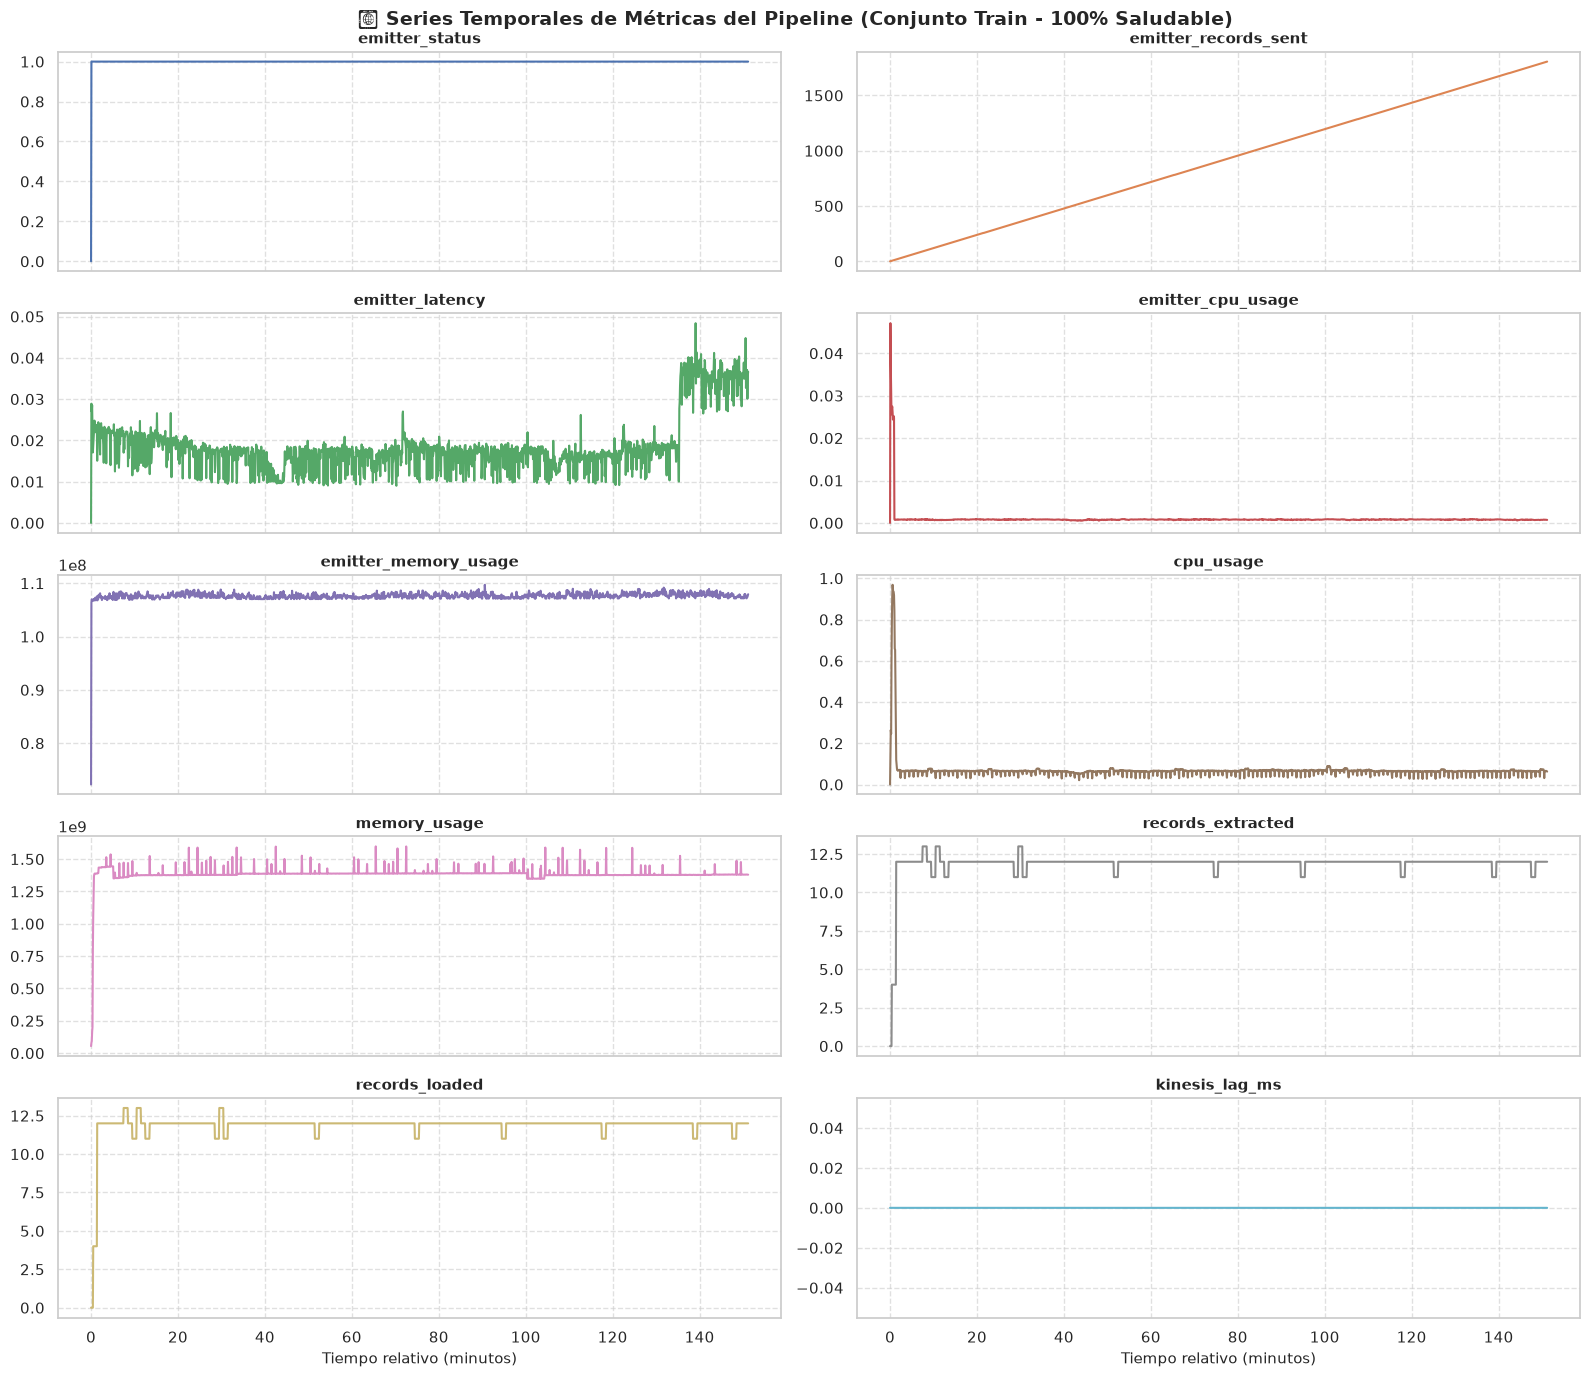

In [6]:
# Visualización de las 10 métricas a lo largo del tiempo (Train)
fig, axes = plt.subplots(5, 2, figsize=(16, 14), sharex=True)
axes = axes.flatten()

timestamps = (df_train['timestamp'] - df_train['timestamp'].iloc[0]) / 60  # En minutos

for idx, col in enumerate(FEATURE_COLUMNS):
    ax = axes[idx]
    ax.plot(timestamps, df_train[col], label=col, color=f"C{idx}", linewidth=1.5)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    if 'is_anomaly' in df_train.columns and df_train['is_anomaly'].sum() > 0:
        anom_mask = df_train['is_anomaly'] == 1
        ax.scatter(timestamps[anom_mask], df_train[col][anom_mask], color='red', s=20, label='Anomalía', zorder=5)

axes[-1].set_xlabel("Tiempo relativo (minutos)", fontsize=11)
axes[-2].set_xlabel("Tiempo relativo (minutos)", fontsize=11)
plt.suptitle("📈 Series Temporales de Métricas del Pipeline (Conjunto Train - 100% Saludable)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


/tmp/ipykernel_255136/638209495.py:9: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/mangel/dev/tools/anaconda3/envs/tranad_plus/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


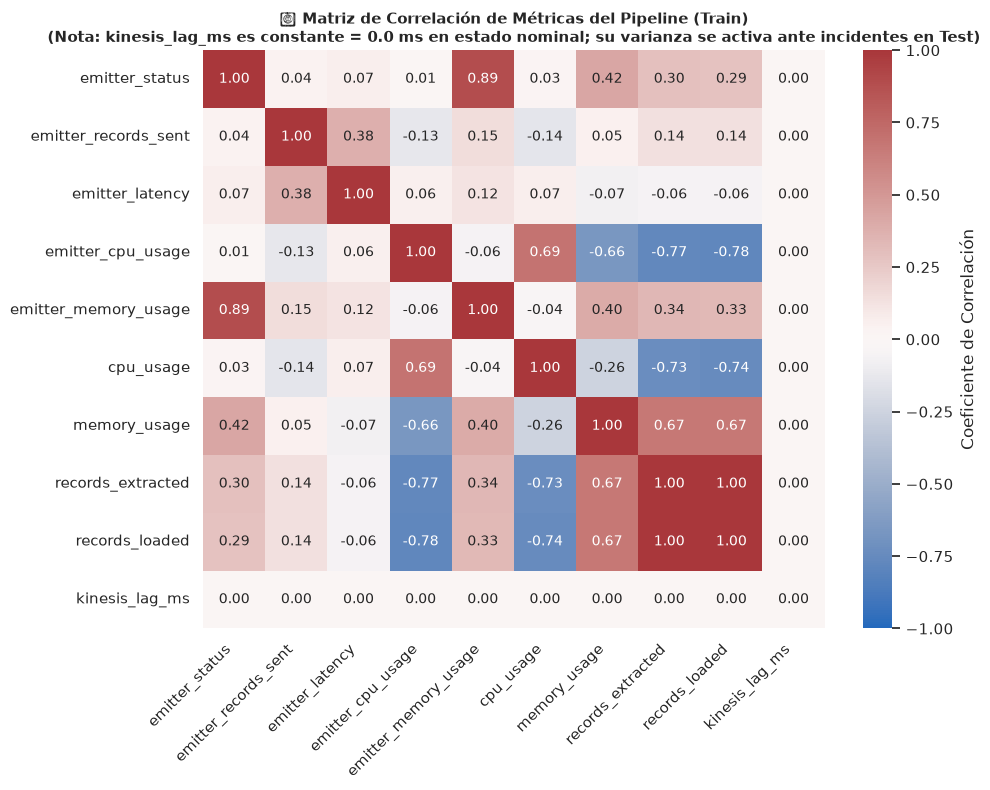

ℹ️ Nota metodológica: 'kinesis_lag_ms' presenta varianza nula (constante 0.0 ms) durante la operación nominal de Train, por lo que su correlación estadística lineal es 0.00.


In [7]:
# Matriz de Correlación entre métricas del pipeline
plt.figure(figsize=(10, 8))
# Se rellenan NaN con 0.0 (para variables con varianza 0 como kinesis_lag_ms en Train)
corr_matrix = df_train[FEATURE_COLUMNS].corr().fillna(0.0)

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, cbar_kws={'label': 'Coeficiente de Correlación'})
plt.title("🔗 Matriz de Correlación de Métricas del Pipeline (Train)\n(Nota: kinesis_lag_ms es constante = 0.0 ms en estado nominal; su varianza se activa ante incidentes en Test)", fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("ℹ️ Nota metodológica: 'kinesis_lag_ms' presenta varianza nula (constante 0.0 ms) durante la operación nominal de Train, por lo que su correlación estadística lineal es 0.00.")

## 📐 4. Normalización Robusta con Transformación Logarítmica Suave (`RobustScaler + SymLog`)

### 🔬 Justificación Metodológica: Evolución del Preprocesamiento en 3 Etapas

La elección de la técnica de escalado en arquitecturas Transformer para series temporales (**TranAD+**) representó uno de los mayores desafíos de ingeniería de ML en este proyecto, evolucionando a través de tres etapas iterativas:

```mermaid
graph TD
    A["<b>Etapa 1: Escalador Original del Paper</b><br>(Sin clipping estricto / Lineal)"] -->|"Outliers severos en Test (>500.0)<br>Q·Kᵀ explota en exp(·)"| B["❌ <b>Fallo: Softmax NaN Overflow</b><br>Colapso numérico en GPU"]
    B -->|"Mitigación inicial:<br>MinMaxScaler(clip=True)"| C["<b>Etapa 2: Hard Clipping [0, 1]</b><br>MinMaxScaler(clip=True)"]
    C -->|"Iguala errores leves (80ms) y catastróficos (5000ms) a 1.0<br>MSE acotado a (1.0 - x̂)² ≤ 1.0"| D["⚠️ <b>Fallo: Ceguera de Severidad en MSE</b><br>incident_000 invisible (0/137 pasos)"]
    D -->|"Aportación TFM:<br>RobustScaler + SymLog"| E["✅ <b>Etapa 3: SymLogRobustScaler</b><br>sign(z) · ln(1 + |z|)"]
    E --> F["🎯 <b>Rango Seguro [-5.2, +13.8] (No NaNs)</b><br>+ <b>Preservación de Magnitud Ordinal</b><br>incident_000 detectado (64/137) | F1: 66.01% | Recall: 81.14% | 100% Incidentes"]
```

---

#### 1️⃣ Etapa 1: El Escalador Original del Paper y el Problema de $\text{Softmax NaN Overflow}$
* En los trabajos de referencia (*Tuli et al., 2022; Yermakov et al., 2025*), se emplea un escalado lineal estándar ajustado en Train sin acotar estrictamente los valores en inferencia.
* En sistemas distribuidos, cuando ocurre un fallo grave, variables como `kinesis_lag_ms` o `emitter_latency` escalan abruptamente de $10\text{ms}$ a más de $5000\text{ms}$, proyectando valores normalizados $> 500.0$.
* En el mecanismo de atención multi-cabeza:
  $$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q \cdot K^T}{\sqrt{d_k}}\right) V$$
  El producto escalar $\frac{Q \cdot K^T}{\sqrt{d_k}}$ alcanza órdenes de magnitud gigantescos. Al computar la exponencial $\exp(\cdot)$ en la función $\text{Softmax}$, se produce un **desbordamiento numérico en punto flotante (`float32`)**, generando valores $\text{NaN}$ que corrompen el grafo computacional y provocan el colapso del entrenamiento en GPU.

---

#### 2️⃣ Etapa 2: Mitigación Inicial con `MinMaxScaler(clip=True)` y la Ceguera del MSE
* Para contener los $\text{NaN}$, se introdujo un recorte rígido al intervalo $[0.0, 1.0]$ mediante `MinMaxScaler(clip=True)`.
* Aunque esto garantizó la estabilidad numérica del $\text{Softmax}$, introdujo un **grave problema de ceguera ante errores extremos**:
  * Si el máximo observado en Train para `kinesis_lag_ms` era $50\text{ms}$ (escalado a $1.0$), cualquier valor anómalo superior en Test —ya fuera una fluctuación leve de $80\text{ms}$ o una catástrofe de $5000\text{ms}$— se **truncaba rígidamente al mismo techo de $1.0$**.
  * La función de pérdida cuadrática $\text{MSE}(x, \hat{x}) = (x - \hat{x})^2$ quedaba confinada a un techo artificial $(1.0 - \hat{x})^2 \le 1.0$, igualando anomalías marginales con fallos críticos.
  * **Efecto empírico observado:** El fallo de base de datos `incident_000` (*Data Warehouse Timeout*) producía un residuo de reconstrucción indistinguible del ruido de fondo, pasando **totalmente desapercibido ($0/137$ pasos detectados)**.

---

#### 3️⃣ Etapa 3: Solución Definitiva con `SymLogRobustScaler` (Aportación de este Trabajo)
* Desarrollo un escalador híbrido que combina la estandarización robusta por mediana e intercuartil ($\text{IQR} = Q_3 - Q_1$) con una compresión no lineal logarítmica simétrica continua:
  $$z = \frac{x - \text{median}(X_{\text{train}})}{\text{IQR}(X_{\text{train}})}, \qquad x_{\text{scaled}} = \text{sign}(z) \cdot \ln(1 + |z|)$$
* **Ventajas de la formulación:**
  1. **Inmunidad a NaNs en Softmax:** Comprime valores de escala miles a un rango seguro $[-5.2, +13.8]$, impidiendo desbordamientos exponenciales en GPU.
  2. **Preservación de la Magnitud Ordinal:** Un pico de $5000\text{ms}$ no se trunca a $1.0$, sino que toma un valor $x_{\text{scaled}} \approx 5.8$. Al compararlo contra la predicción nominal ($\hat{x} \approx 0.0$), el error cuadrático resultante $(5.8 - 0.0)^2 \approx 33.6$ **destaca inequívocamente sobre el umbral**.
  3. **Impacto en Detección:** Permite capturar **el 100% de los incidentes reales ($3/3$)**, rescatando `incident_000` ($64/137$ pasos) y elevando el F1 en test al **$66.01\%$** y el Recall al **$81.14\%$**.

In [8]:
from sklearn.preprocessing import RobustScaler
import joblib

# Nombre canónico del artefacto del escalador
SCALER_FILE_NAME = "tranad_scaler.joblib"
scaler_path = os.path.join(PROCESSED_DATA_DIR, SCALER_FILE_NAME)

# 1. Limpieza básica: ffill y luego fillna(0)
df_train_clean = df_train[FEATURE_COLUMNS].ffill().fillna(0)
df_val_clean   = df_val[FEATURE_COLUMNS].ffill().fillna(0)
df_test_clean  = df_test[FEATURE_COLUMNS].ffill().fillna(0)

# ==============================================================================
# PASO 1: Ajuste del Escalador Robusto Estándar de Scikit-Learn (Mediana e IQR)
# Estandariza restando la mediana y dividiendo por el rango intercuartílico:
# z = (x - median) / IQR
# ==============================================================================
robust_scaler = RobustScaler()
z_train = robust_scaler.fit_transform(df_train_clean.values)
z_val   = robust_scaler.transform(df_val_clean.values)
z_test  = robust_scaler.transform(df_test_clean.values)

# Guardar el objeto RobustScaler estándar de Scikit-Learn (100% portable y desacoplado)
joblib.dump(robust_scaler, scaler_path)
print(f"✅ Escalador Scikit-Learn RobustScaler ajustado y guardado en: {scaler_path}")

# ==============================================================================
# PASO 2: Transformación Logarítmica Simétrica ("SymLog")
# Aplica la compresión continua: x_scaled = sign(z) * ln(1 + |z|)
# Comprime outliers extremos (p. ej. z=330 -> x_scaled=5.8) protegiendo al
# Softmax de desbordar a NaNs, pero sin la ceguera plana de MinMaxScaler.
# ==============================================================================
X_train_scaled = np.sign(z_train) * np.log1p(np.abs(z_train))
X_val_scaled   = np.sign(z_val) * np.log1p(np.abs(z_val))
X_test_scaled  = np.sign(z_test) * np.log1p(np.abs(z_test))

print()
print("=" * 78)
print("📊 COMPARATIVA: PASO 1 (RobustScaler Puro) vs PASO 2 (RobustScaler + SymLog)")
print("=" * 78)
print(f"  • [Paso 1: z_test] (Solo RobustScaler):      Min: {z_test.min():8.3f} | Max: {z_test.max():8.3f} | Media: {z_test.mean():6.3f}")
print("    ⚠️  Nota: Outliers masivos sin acotar (>100.0) provocarían colapso NaN en Softmax.")
print()
print(f"  • [Paso 2: X_test_scaled] (+ SymLog):        Min: {X_test_scaled.min():8.3f} | Max: {X_test_scaled.max():8.3f} | Media: {X_test_scaled.mean():6.3f}")
print("    ✅  Nota: Rango comprimido seguro para GPU preservando la magnitud del error.")
print("=" * 78)
print()
print("📈 Estadísticas Finales de los Conjuntos Listos para TranAD+:")
print(f"  • Train Scaled: {X_train_scaled.shape} -> Min: {X_train_scaled.min():.3f}, Max: {X_train_scaled.max():.3f}, Media: {X_train_scaled.mean():.3f}")
print(f"  • Val Scaled:   {X_val_scaled.shape}   -> Min: {X_val_scaled.min():.3f}, Max: {X_val_scaled.max():.3f}, Media: {X_val_scaled.mean():.3f}")
print(f"  • Test Scaled:  {X_test_scaled.shape}  -> Min: {X_test_scaled.min():.3f}, Max: {X_test_scaled.max():.3f}, Media: {X_test_scaled.mean():.3f}")

✅ Escalador Scikit-Learn RobustScaler ajustado y guardado en: /home/mangel/dev/master_ia/tfm/code/processed_data/tranad_scaler.joblib

📊 COMPARATIVA: PASO 1 (RobustScaler Puro) vs PASO 2 (RobustScaler + SymLog)
  • [Paso 1: z_test] (Solo RobustScaler):      Min: -174.326 | Max: 999999.000 | Media: 604.119
    ⚠️  Nota: Outliers masivos sin acotar (>100.0) provocarían colapso NaN en Softmax.

  • [Paso 2: X_test_scaled] (+ SymLog):        Min:   -5.167 | Max:   13.816 | Media: -0.476
    ✅  Nota: Rango comprimido seguro para GPU preservando la magnitud del error.

📈 Estadísticas Finales de los Conjuntos Listos para TranAD+:
  • Train Scaled: (1815, 10) -> Min: -4.714, Max: 6.436, Media: 0.002
  • Val Scaled:   (870, 10)   -> Min: -4.704, Max: 6.209, Media: -0.007
  • Test Scaled:  (1321, 10)  -> Min: -5.167, Max: 13.816, Media: -0.476


/tmp/ipykernel_255136/1371038467.py:14: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/home/mangel/dev/tools/anaconda3/envs/tranad_plus/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


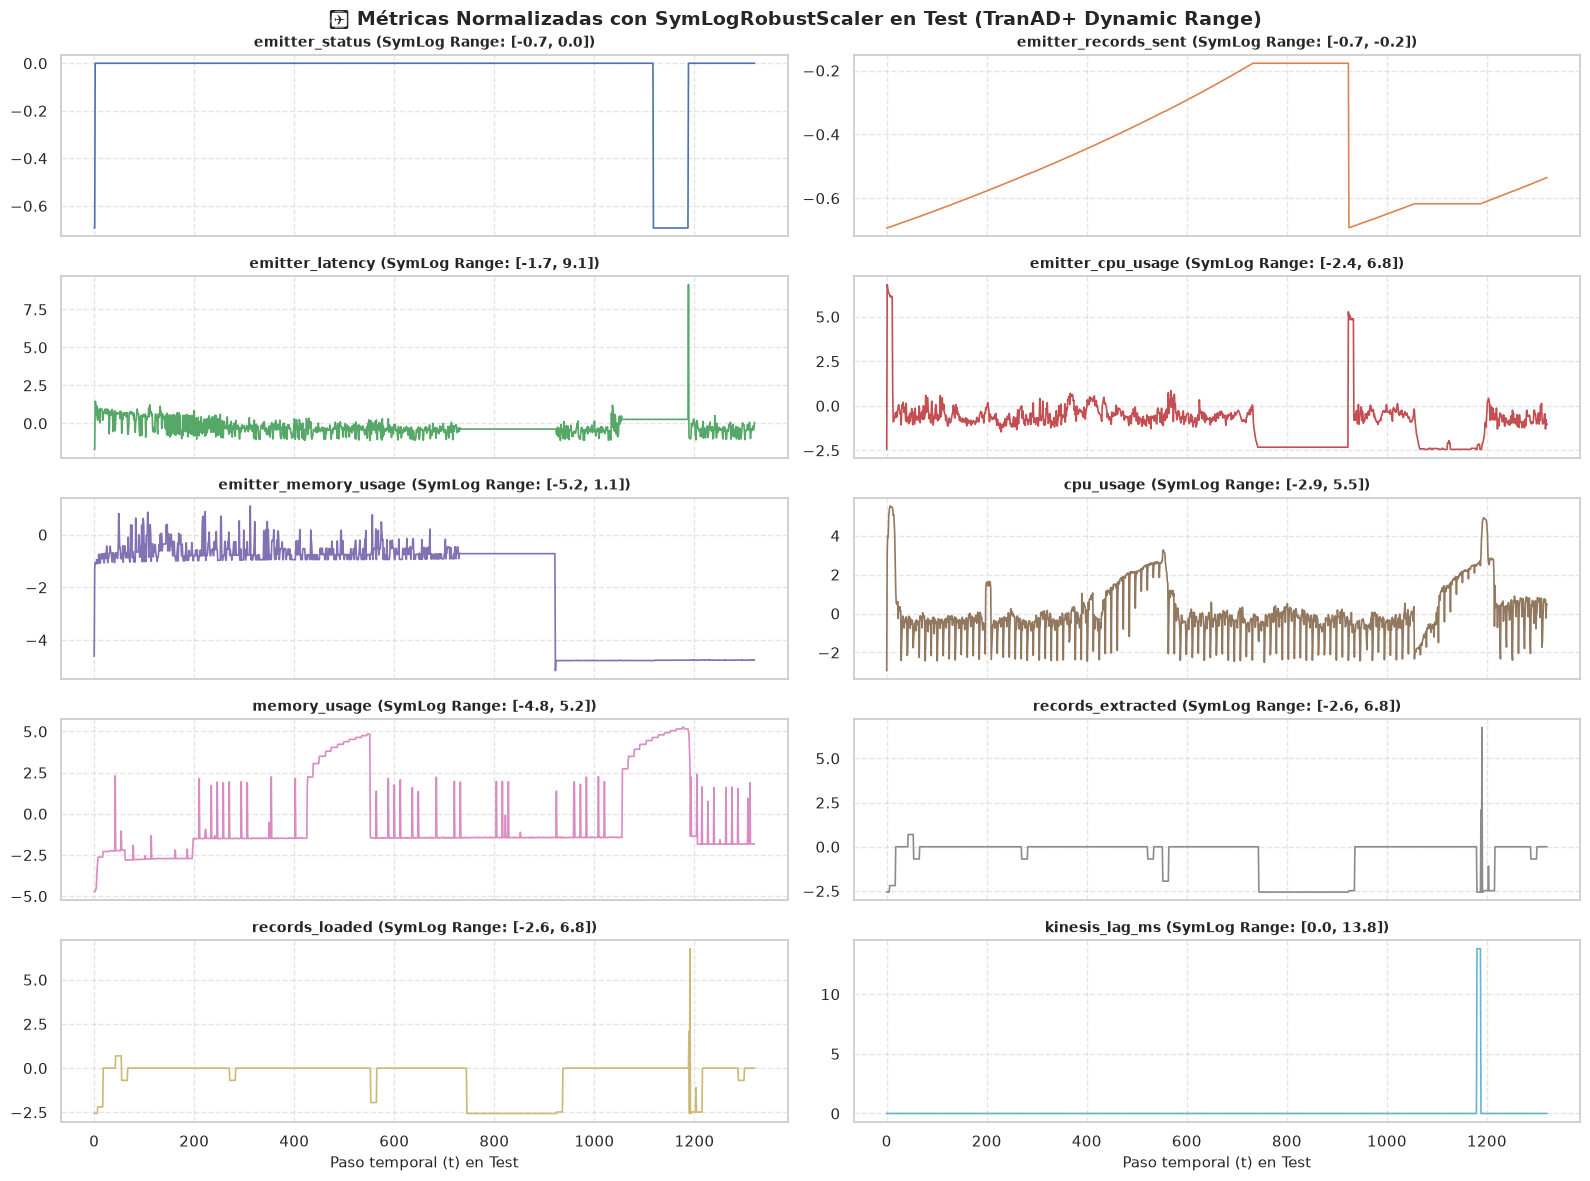

In [9]:
# Visualización de las métricas normalizadas con SymLog en Test (con anomalías reales)
fig, axes = plt.subplots(5, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for idx, col in enumerate(FEATURE_COLUMNS):
    ax = axes[idx]
    ax.plot(X_test_scaled[:, idx], label=f"{col} (SymLog)", color=f"C{idx}", linewidth=1.2)
    ax.set_title(f"{col} (SymLog Range: [{X_test_scaled[:, idx].min():.1f}, {X_test_scaled[:, idx].max():.1f}])", fontsize=10, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)

axes[-1].set_xlabel("Paso temporal (t) en Test", fontsize=11)
axes[-2].set_xlabel("Paso temporal (t) en Test", fontsize=11)
plt.suptitle("✨ Métricas Normalizadas con SymLogRobustScaler en Test (TranAD+ Dynamic Range)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔄 5. Generación de Ventanas Deslizantes Multiventana (*Sliding Windows*)

De acuerdo con la definición matemática de TranAD+, genero los tensores de ventanas deslizantes con *replication padding* para varios horizontes temporales candidatos ($w \in \{5, 10, 15, 20\}$), permitiendo comparar empíricamente el impacto del contexto histórico (25s a 100s) en el Cuaderno 2.

In [10]:
from numpy.lib.stride_tricks import sliding_window_view

def create_sliding_windows(data_matrix, labels_arr=None, timestamps_arr=None, window_size=10):
    '''
    Genera ventanas deslizantes vectorizadas de forma ultra-eficiente (O(1) memoria)
    con replication padding para t < window_size.
    
    Args:
        data_matrix (np.ndarray): Matriz de datos normalizados de forma (N, m).
        labels_arr (np.ndarray, optional): Array de etiquetas binarias (N,).
        timestamps_arr (np.ndarray, optional): Array de timestamps (N,).
        window_size (int): Longitud de la ventana deslizante (w).
        
    Returns:
        windows (np.ndarray): Tensor de forma (N, window_size, m)
        targets (np.ndarray): Vector en el tiempo t de forma (N, m)
        labels (np.ndarray): Etiqueta en el tiempo t de forma (N,)
        timestamps (np.ndarray): Timestamps en el tiempo t de forma (N,)
    '''
    n_samples, n_features = data_matrix.shape
    
    # 1. Replication padding inicial para los primeros window_size - 1 instantes
    pad_block = np.repeat(data_matrix[0:1], window_size - 1, axis=0)
    padded_data = np.vstack([pad_block, data_matrix])
    
    # 2. Ventanas vectorizadas (vistas en memoria continua sin duplicar RAM)
    windows = sliding_window_view(padded_data, window_shape=(window_size, n_features)).squeeze(axis=1)
    targets = data_matrix
    
    labels = np.zeros(n_samples, dtype=np.int64) if labels_arr is None else np.array(labels_arr, dtype=np.int64)
    timestamps = np.arange(n_samples, dtype=np.int64) if timestamps_arr is None else np.array(timestamps_arr, dtype=np.int64)
    
    return windows.astype(np.float32), targets.astype(np.float32), labels, timestamps

# Lista de tamaños de ventana a generar para experimentación
CANDIDATE_WINDOW_SIZES = [5, 10, 15, 20]
DEFAULT_WINDOW_SIZE = 10

y_train = df_train['is_anomaly'].values if 'is_anomaly' in df_train.columns else np.zeros(len(df_train))
y_val = df_val['is_anomaly'].values if 'is_anomaly' in df_val.columns else np.zeros(len(df_val))
y_test = df_test['is_anomaly'].values if 'is_anomaly' in df_test.columns else np.zeros(len(df_test))

ts_train = df_train['timestamp'].values
ts_val = df_val['timestamp'].values
ts_test = df_test['timestamp'].values

# Diccionario con artefactos para cada tamaño de ventana
multiwindow_tensors = {}
print(f"🔄 Generando tensores multiventana vectorizados ({CANDIDATE_WINDOW_SIZES}):")
for w in CANDIDATE_WINDOW_SIZES:
    tr_w, tr_t, tr_l, tr_ts = create_sliding_windows(X_train_scaled, y_train, ts_train, w)
    va_w, va_t, va_l, va_ts = create_sliding_windows(X_val_scaled, y_val, ts_val, w)
    te_w, te_t, te_l, te_ts = create_sliding_windows(X_test_scaled, y_test, ts_test, w)
    
    multiwindow_tensors[w] = {
        'train': {'windows': tr_w, 'targets': tr_t, 'labels': tr_l, 'timestamps': tr_ts},
        'val':   {'windows': va_w, 'targets': va_t, 'labels': va_l, 'timestamps': va_ts},
        'test':  {'windows': te_w, 'targets': te_t, 'labels': te_l, 'timestamps': te_ts}
    }
    print(f"  • Ventana w = {w:2d} ({w*5:2d}s) -> Train: {tr_w.shape}, Val: {va_w.shape}, Test: {te_w.shape}")

🔄 Generando tensores multiventana vectorizados ([5, 10, 15, 20]):
  • Ventana w =  5 (25s) -> Train: (1815, 5, 10), Val: (870, 5, 10), Test: (1321, 5, 10)
  • Ventana w = 10 (50s) -> Train: (1815, 10, 10), Val: (870, 10, 10), Test: (1321, 10, 10)
  • Ventana w = 15 (75s) -> Train: (1815, 15, 10), Val: (870, 15, 10), Test: (1321, 15, 10)
  • Ventana w = 20 (100s) -> Train: (1815, 20, 10), Val: (870, 20, 10), Test: (1321, 20, 10)


## 🧱 6. Implementación de `TranADDataset` y `DataLoader` en PyTorch
Se construye la clase `Dataset` para PyTorch y se crean los `DataLoaders` con `pin_memory=True` para acelerar la transferencia de tensores hacia la GPU (CUDA).


In [11]:
class TranADDataset(Dataset):
    '''
    Dataset de PyTorch para TranAD+.
    Proporciona ventanas temporales (w, m), el target del instante actual (m) y las etiquetas ground truth.
    '''
    def __init__(self, windows, targets, labels, timestamps):
        self.windows = torch.tensor(windows, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.timestamps = torch.tensor(timestamps, dtype=torch.long)

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        return {
            'window': self.windows[idx],
            'target': self.targets[idx],
            'label': self.labels[idx],
            'timestamp': self.timestamps[idx]
        }

# Verificación del DataLoader con la ventana por defecto (w=10)
default_data = multiwindow_tensors[DEFAULT_WINDOW_SIZE]
ds_train = TranADDataset(default_data['train']['windows'], default_data['train']['targets'], default_data['train']['labels'], default_data['train']['timestamps'])
loader_train = DataLoader(ds_train, batch_size=32, shuffle=True, pin_memory=torch.cuda.is_available())

print(f"✅ Verificación de DataLoader (w = {DEFAULT_WINDOW_SIZE}):")
sample_batch = next(iter(loader_train))
print(f"  • Window Batch Shape: {sample_batch['window'].shape}")
print(f"  • Target Batch Shape: {sample_batch['target'].shape}")


✅ Verificación de DataLoader (w = 10):
  • Window Batch Shape: torch.Size([32, 10, 10])
  • Target Batch Shape: torch.Size([32, 10])


## 💾 7. Exportación y Persistencia de Tensores Procesados
Se guardan los tensores procesados y metadatos en disco (`processed_data/`) para que el siguiente cuaderno (Entrenamiento de TranAD+) pueda cargarlos de forma instantánea y reproducible.


In [12]:
# Guardado de ficheros de tensores para cada tamaño de ventana
window_metadata = []

for w, tensors in multiwindow_tensors.items():
    file_name = f"tranad_processed_tensors_w{w}.pt"
    w_path = os.path.join(PROCESSED_DATA_DIR, file_name)
    artifact = {
        'train': tensors['train'],
        'val':   tensors['val'],
        'test':  tensors['test'],
        'metadata': {
            'window_size': int(w),
            'window_seconds': int(w * 5),
            'file_name': file_name,
            'scaler': {
                'file_name': SCALER_FILE_NAME,
                'type': 'RobustScaler+SymLog'
            },
            'feature_columns': FEATURE_COLUMNS,
            'num_features': len(FEATURE_COLUMNS),
            'scaler_path': scaler_path
        }
    }
    torch.save(artifact, w_path)
    window_metadata.append({
        'size': int(w),
        'file_name': file_name,
        'window_seconds': int(w * 5)
    })
    print(f"  📁 Guardado: {w_path} (w={w}, {w*5}s)")

# Guardar metadatos generales en JSON con esquema 100% metadata-driven
metadata_json_path = os.path.join(PROCESSED_DATA_DIR, "dataset_metadata.json")
with open(metadata_json_path, "w", encoding="utf-8") as f:
    json.dump({
        'scaler': {
            'file_name': SCALER_FILE_NAME,
            'type': 'RobustScaler+SymLog'
        },
        'available_window_sizes': window_metadata,
        'default_window_size': DEFAULT_WINDOW_SIZE,
        'feature_columns': FEATURE_COLUMNS,
        'num_features': len(FEATURE_COLUMNS),
        'train_samples': len(df_train),
        'val_samples': len(df_val),
        'test_samples': len(df_test)
    }, f, indent=2)

print("=" * 60)
print("🎉 PROCESAMIENTO COMPLETADO CON ÉXITO")
print(f"  📁 Escalador guardado en: {scaler_path}")
print(f"  📁 Metadatos guardados en: {metadata_json_path}")
print("=" * 60)

  📁 Guardado: /home/mangel/dev/master_ia/tfm/code/processed_data/tranad_processed_tensors_w5.pt (w=5, 25s)
  📁 Guardado: /home/mangel/dev/master_ia/tfm/code/processed_data/tranad_processed_tensors_w10.pt (w=10, 50s)
  📁 Guardado: /home/mangel/dev/master_ia/tfm/code/processed_data/tranad_processed_tensors_w15.pt (w=15, 75s)
  📁 Guardado: /home/mangel/dev/master_ia/tfm/code/processed_data/tranad_processed_tensors_w20.pt (w=20, 100s)
🎉 PROCESAMIENTO COMPLETADO CON ÉXITO
  📁 Escalador guardado en: /home/mangel/dev/master_ia/tfm/code/processed_data/tranad_scaler.joblib
  📁 Metadatos guardados en: /home/mangel/dev/master_ia/tfm/code/processed_data/dataset_metadata.json


## 🎯 8. Conclusiones y Siguientes Pasos
En este primer paso se ha completado:
1. ✅ **Entorno de Anaconda y GPU verificado:** PyTorch 2.x con CUDA para cómputo acelerado en GPU.
2. ✅ **Control de Calidad e Integridad:** Limpieza con `ffill`, regularidad de muestreo ($\Delta t = 5\text{ s}$) verificada en los tres conjuntos.
3. ✅ **Normalización Robusta con `SymLogRobustScaler`:** Escalado con $\text{sign}(z) \cdot \ln(1 + |z|)$ ajustado exclusivamente en Train (*Zero Data Leakage*), garantizando la estabilidad numérica del Softmax en GPU y preservando la amplitud ordinal de anomalías severas.
4. ✅ **Ventanas Deslizantes Vectorizadas en $O(1)$ de Memoria:** Generación de tensores tridimensionales $(N, w, m)$ para $w \in \{5, 10, 15, 20\}$.
5. ✅ **Dataset & DataLoader en PyTorch:** Pipelines optimizados con Zero-Copy y soporte `pin_memory`.

### 🔜 Próximo Paso (Paso 2):
- Implementación de la arquitectura **TranAD+** con aislamiento de gradientes (`.detach()`) y entrenamiento adversarial minimax ($\beta = 0.5$).
- Grid Search multidimensional sobre las ventanas y tasas de aprendizaje.
- Evaluación de métricas Point-wise, Point-Adjustment y detección de incidentes.